# Project: Investigate a Dataset - No-show appointments

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

>The **No-show Appointments** dataset contains information on 100,000 medical appointments in Brazil, focusing on whether or not patients showed up for their scheduled appointments.
Each record represents a single patient appointment and includes several demographic and behavioral attributes.

#### Key Variables

| Column Name | Description |
| :--- | :--- |
| **ScheduledDay** | The date on which the patient scheduled the appointment. |
| **AppointmentDay** | The actual date of the medical appointment. |
| **Neighbourhood** | The location (neighborhood) of the hospital or clinic. |
| **Scholarship** | Indicates whether the patient is enrolled in **Bolsa Família**, a Brazilian social welfare program. |
| **Hipertension, Diabetes, Alcoholism, Handcap** | Binary indicators (0 or 1) for the patient’s medical or physical conditions. |
| **SMS\_received** | Specifies whether the patient received an SMS reminder about their appointment. |
| **No-show** | **The Target Variable.** **"No"** means the patient **showed up**; **"Yes"** means the patient **did not attend** the appointment. |

#### Dataset Columns

The dataset includes the following columns:

`['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']`


### Question(s) for Analysis
>**Tip**: Clearly state one or more questions that you plan on exploring over the course of the report. You will address these questions in the **data analysis** and **conclusion** sections. Try to build your report around the analysis of at least one dependent variable and three independent variables. If you're not sure what questions to ask, then make sure you familiarize yourself with the dataset, its variables and the dataset context for ideas of what to explore.

> **Tip**: Once you start coding, use NumPy arrays, Pandas Series, and DataFrames where appropriate rather than Python lists and dictionaries. Also, **use good coding practices**, such as, define and use functions to avoid repetitive code. Use appropriate comments within the code cells, explanation in the mark-down cells, and meaningful variable names. 

In [1]:
# Use this cell to set up import statements for all of the packages that you
#   plan to use.

# While optional for current notebooks, if you are having trouble with visualizations,
#   remember to include a 'magic word' so that your visualizations are plotted
#   inline with the notebook. See this page for more:
#   http://ipython.readthedocs.io/en/stable/interactive/magics.html

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<a id='wrangling'></a>
## Data Wrangling

> **Tip**: In this section of the report, you will load in the data, check for cleanliness, and then trim and clean your dataset for analysis. Make sure that you **document your data cleaning steps in mark-down cells precisely and justify your cleaning decisions.**


### General Properties
> **Tip**: You should _not_ perform too many operations in each cell. Create cells freely to explore your data. One option that you can take with this project is to do a lot of explorations initially. This does not have to be organized, but make sure you use enough comments to understand the purpose of each code cell. Then, after you're done with your analysis, trim the excess and organize your steps so that you have a flowing, cohesive report.

In [2]:
# Load your data and print out a few lines. What is the size of your dataframe? 
#   Perform operations to inspect data types and look for instances of missing
#   or possibly errant data. There are at least 4 - 6 methods you can call on your
#   dataframe to obtain this information.
df = pd.read_csv('Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
df.shape

(110527, 14)

In [4]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')


### Data Cleaning
> **Tip**: Make sure that you keep your reader informed on the steps that you are taking in your investigation. Follow every code cell, or every set of related code cells, with a markdown cell to describe to the reader what was found in the preceding cell(s). Try to make it so that the reader can then understand what they will be seeing in the following cell(s).
 

In [5]:
# After discussing the structure of the data and any problems that need to be
#   cleaned, perform those cleaning steps in the second part of this section.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
df.nunique()

PatientId          62299
AppointmentID     110527
Gender                 2
ScheduledDay      103549
AppointmentDay        27
Age                  104
Neighbourhood         81
Scholarship            2
Hipertension           2
Diabetes               2
Alcoholism             2
Handcap                5
SMS_received           2
No-show                2
dtype: int64

In [9]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [10]:
df.duplicated().sum()

0

#### Convert ScheduledDay e AppointmentDay to datetime

In [11]:
df.ScheduledDay = pd.to_datetime(df.ScheduledDay)
df.AppointmentDay = pd.to_datetime(df.AppointmentDay)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hipertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handcap         110527 non-null  int64              
 12  SMS_received    110527 non-null  int64              
 13  No-show       

#### Convert **'No-show'** to boolean values (**1 = did not show up**, **0 = showed up**)

In [12]:
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hipertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handcap         110527 non-null  int64              
 12  SMS_received    110527 non-null  int64              
 13  No-show       

<a id='eda'></a>
## Exploratory Data Analysis


### Research Question 1 - In which neighborhoods with an above-average number of appointments do we observe the highest proportion of patients who did not show up for their consultations?

In [13]:
# Use this, and more code cells, to explore your data. Don't forget to add
#   Markdown cells to document your observations and findings.

# Count the number of appointments per neighborhood
appointments_per_neighbourhood = df['Neighbourhood'].value_counts()

# Calculate the average number of appointments
mean_appointments = appointments_per_neighbourhood.mean()

# Select only neighborhoods with above-average appointment counts
above_avg_neighbourhoods = appointments_per_neighbourhood[appointments_per_neighbourhood > mean_appointments]

# Filter the original DataFrame to include only those neighborhoods
df_filtered = df[df['Neighbourhood'].isin(above_avg_neighbourhoods.index)]

# Calculate the proportion of no-shows for each neighborhood
no_show_rate = (
    df_filtered.groupby('Neighbourhood')['No-show']
    .mean()
    .sort_values(ascending=False)
)

# Select the top 10 neighborhoods with the highest no-show rates
top10_no_show = no_show_rate.head(10)

# Display results in the console
print("Top 10 neighborhoods (with above-average appointment counts) with the highest no-show proportions:\n")
print(top10_no_show)

Top 10 neighborhoods (with above-average appointment counts) with the highest no-show proportions:

Neighbourhood
ITARARÉ              0.262664
JESUS DE NAZARETH    0.243954
ILHA DO PRÍNCIPE     0.234775
CARATOÍRA            0.230409
ANDORINHAS           0.230327
GURIGICA             0.225966
MARUÍPE              0.222923
CRUZAMENTO           0.217454
SÃO JOSÉ             0.216490
ROMÃO                0.213995
Name: No-show, dtype: float64


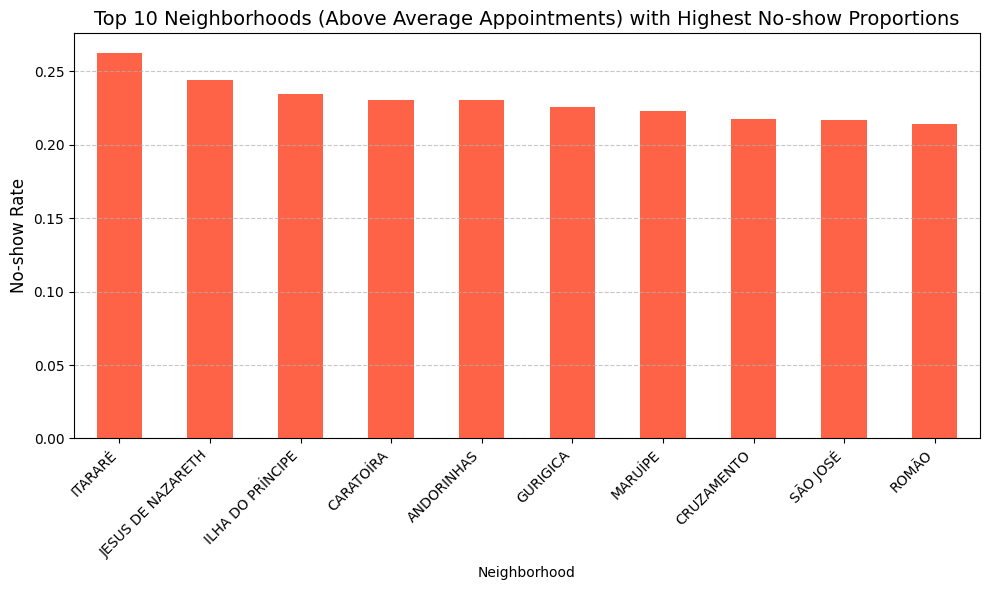

In [14]:
# Create a bar chart
plt.figure(figsize=(10,6))
top10_no_show.plot(kind='bar', color='tomato')

# Customize the chart
plt.title('Top 10 Neighborhoods (Above Average Appointments) with Highest No-show Proportions', fontsize=14)
plt.xlabel('Neighborhood')
plt.ylabel('No-show Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the chart
plt.show()

### Research Question 2 - Which patient characteristics are the strongest predictors of no-show?

In [15]:
# Continue to explore the data to address your additional research
#   questions. Add more headers as needed if you have more questions to
#   investigate.

#### Create Wait_Days
Logic: Waiting time is a very strong predictor. The longer the interval, the greater the chance the patient will forget or change plans.

In [16]:
# Converter o Timedelta para um número inteiro de dias (Wait_Days)
df['Wait_Days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df.Wait_Days

0         -1
1         -1
2         -1
3         -1
4         -1
          ..
110522    34
110523    34
110524    40
110525    40
110526    40
Name: Wait_Days, Length: 110527, dtype: int64

In [17]:
# Calculating the average wait days for those who missed (1) and those who showed up (0)
average_wait_days = df.groupby('No-show')['Wait_Days'].mean()

print("Average Wait Days:")
print(average_wait_days)

Average Wait Days:
No-show
0     7.754659
1    14.831489
Name: Wait_Days, dtype: float64


In [18]:
# The lower bound must be less than the minimum value (-7)
min_wait = -7
max_wait = 178

# Defining bins (time intervals):
# 1. Negative and 0 values (scheduled on the same day/after the appointment)
# 2. 1 to 7 days
# 3. 8 to 30 days
# 4. 31 to 90 days
# 5. 91 up to the maximum
bins = [min_wait - 1, 0, 7, 30, 90, max_wait + 1]
# Resulting Bins: [-8, 0, 7, 30, 90, 179]

# There must be N-1 labels relative to the number of bins
labels = ['Wait_<=_0_days', '1-7_days', '8-30_days', '31-90_days', '91-178_days']

# Creating the new categorical column
df['Wait_Days_Group'] = pd.cut(
    df['Wait_Days'],
    bins=bins,
    labels=labels,
    right=True,
    # include_lowest=True ensures that the lower bound of the first bin (-8) is included
    include_lowest=True
)

# Calculating the no-show rate for each group
rate_by_wait_group = df.groupby('Wait_Days_Group')['No-show'].mean().sort_values(ascending=False)

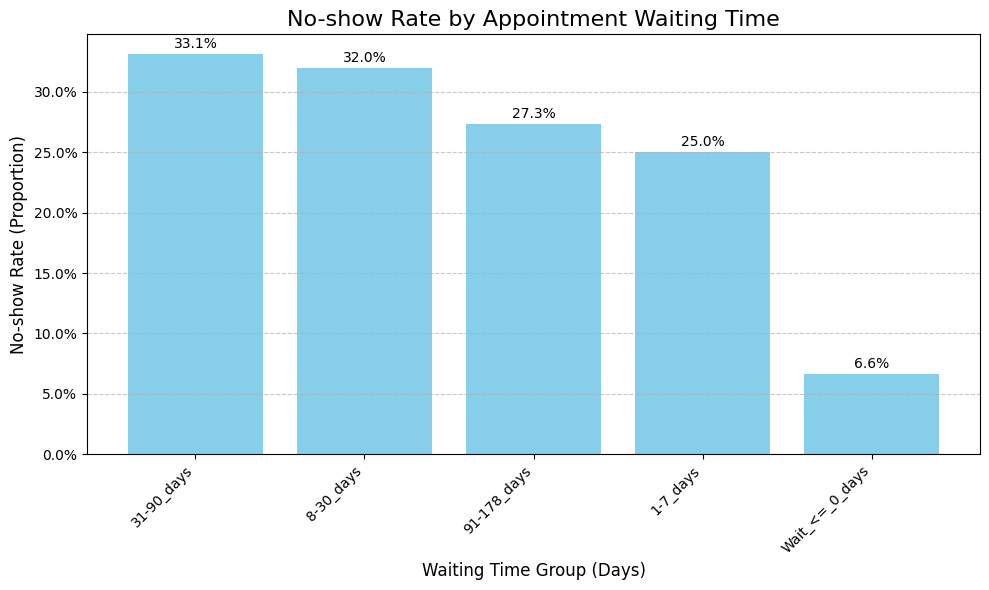

In [19]:
# Define data for plotting
groups = rate_by_wait_group.index
rates = rate_by_wait_group.values

# Create the Bar Chart
plt.figure(figsize=(10, 6))

# Plot the bars
plt.bar(groups, rates, color='skyblue')

# Define title and labels
plt.title('No-show Rate by Appointment Waiting Time', fontsize=16)
plt.xlabel('Waiting Time Group (Days)', fontsize=12)
plt.ylabel('No-show Rate (Proportion)', fontsize=12)

# Format y-axis ticks as percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# Rotate x-labels for better readability and align to the right
plt.xticks(rotation=45, ha='right')

# Add values on top of bars for better interpretation
for i, rate in enumerate(rates):
    plt.text(i, rate + 0.005, f'{rate:.1%}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

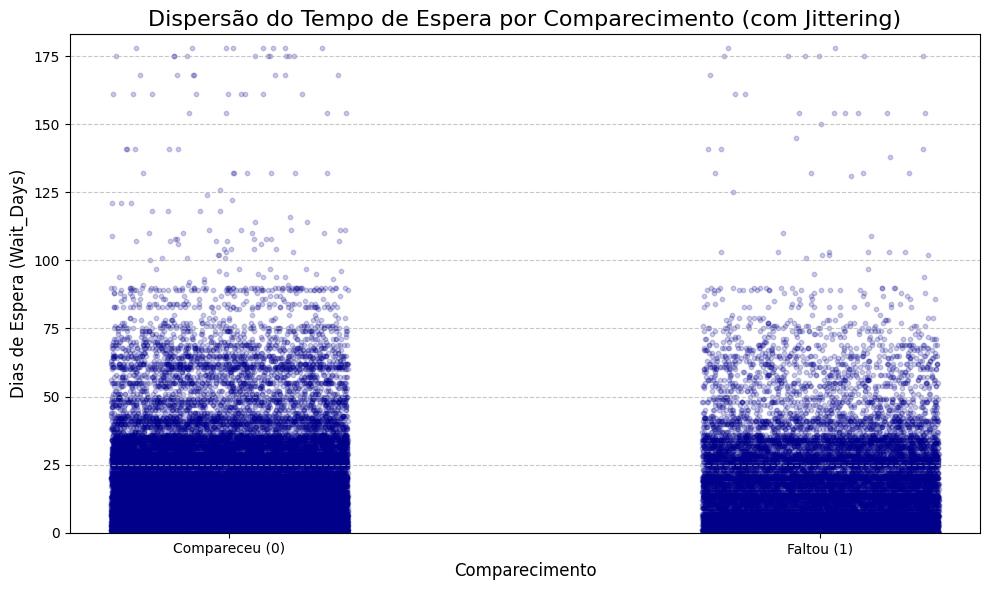

In [20]:
plt.figure(figsize=(10, 6))

# 1. Aplicar Jittering (Ruído Aleatório) ao Eixo X (No-show)
# O jittering é crucial aqui para separar os pontos verticalmente sobrepostos.
# Adicionamos um número aleatório entre -0.2 e 0.2 ao valor binário de No-show (0 ou 1).
jitter_amount = 0.2
x_jittered = df['No-show'] + np.random.uniform(-jitter_amount, jitter_amount, size=len(df))

# 2. Plotar o Gráfico de Dispersão
plt.scatter(
    x=x_jittered,
    y=df['Wait_Days'],
    alpha=0.2,            # Transparência: essencial para visualizar a densidade
    s=10,                 # Tamanho do ponto
    color='darkblue'
)

# 3. Formatação (em Português)
plt.title('Dispersão do Tempo de Espera por Comparecimento (com Jittering)', fontsize=16)
plt.xlabel('Comparecimento', fontsize=12)
plt.ylabel('Dias de Espera (Wait_Days)', fontsize=12)

# Corrigir os ticks do eixo X
plt.xticks([0, 1], ['Compareceu (0)', 'Faltou (1)'])

# Limitar o eixo Y (opcional, mas recomendado)
all_wait_days = df['Wait_Days']
# O Gráfico de Dispersão tradicionalmente não usa percentil, mas podemos limitar se houver outliers
plt.ylim(0, all_wait_days.max() + 5) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

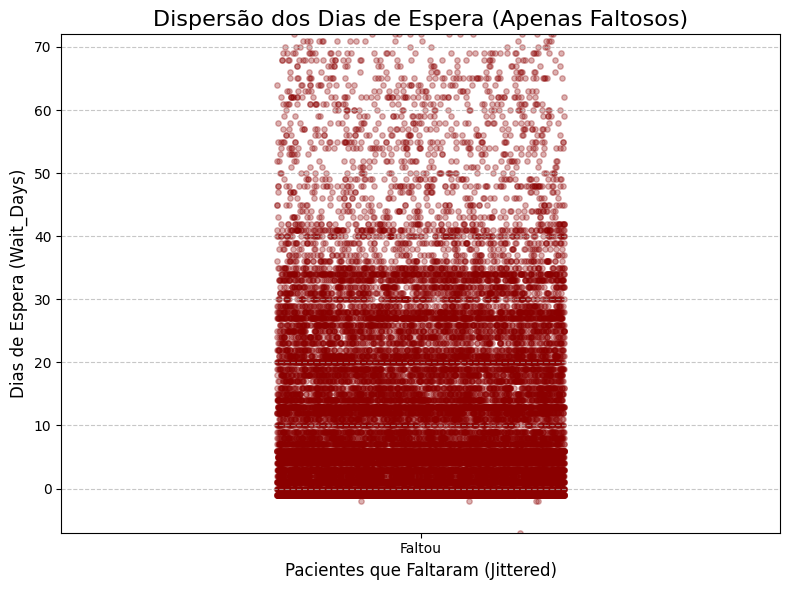

In [21]:
# 1. Filtrar o DataFrame para incluir APENAS quem faltou (No-show == 1)
df_missed = df[df['No-show'] == 1].copy() # Usar .copy() para evitar SettingWithCopyWarning

# 2. Criar um Eixo X Falso (com Jitter)
# O Jitter é aplicado ao valor constante 1 (representando 'faltou')
jitter_amount = 0.2
df_missed['Jittered_X'] = 1 + np.random.uniform(-jitter_amount, jitter_amount, size=len(df_missed))


# --- CÓDIGO DO GRÁFICO (APENAS PLT) ---

plt.figure(figsize=(8, 6))

# 1. Plotar o Gráfico de Dispersão
plt.scatter(
    x=df_missed['Jittered_X'],
    y=df_missed['Wait_Days'],
    alpha=0.3,               # Transparência para ver a densidade
    s=15,                    # Tamanho do ponto
    color='darkred'
)

# 2. Formatação (em Português)
plt.title('Dispersão dos Dias de Espera (Apenas Faltosos)', fontsize=16)
plt.xlabel('Pacientes que Faltaram (Jittered)', fontsize=12)
plt.ylabel('Dias de Espera (Wait_Days)', fontsize=12)

# Corrigir os ticks do eixo X para mostrar apenas o rótulo central
plt.xticks([1], ['Faltou'])
plt.xlim(1 - 0.5, 1 + 0.5) # Ajusta os limites do eixo X para centralizar o ponto 1

# Limitar o eixo Y (opcional, mas recomendado)
wait_days_missed = df_missed['Wait_Days']
plt.ylim(wait_days_missed.min(), wait_days_missed.quantile(0.99))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
# --- ANÁLISE 1: MÉDIA DE IDADE ---

print("--- 1. Média de Idade por Grupo de Comparecimento ---")
# Calculando a média de idade para quem faltou (1) e quem compareceu (0)
media_idade = df.groupby('No-show')['Age'].mean()

print("Média de Idade:")
print(media_idade)

# --- ANÁLISE 2: TAXA DE FALTA POR FAIXA ETÁRIA ---

print("\n--- 2. Taxa de Falta por Faixa Etária ---")

# 1. Definir as Faixas (Bins) e Rótulos (Labels)
# Faixas sugeridas: 0-18, 19-30, 31-50, 51+
# Usamos o valor mínimo de -1 para incluir a idade 0 corretamente.
bins_age = [-1, 18, 30, 50, df['Age'].max() + 1] # +1 garante que o máximo seja incluído
labels_age = ['0-18_anos', '19-30_anos', '31-50_anos', '51+_anos']

# 2. Criar a nova coluna categórica 'Age_Group'
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins_age,
    labels=labels_age,
    right=True,
    include_lowest=True
)

# 3. Calcular a Taxa de Não Comparecimento (Média de No-show) para cada grupo de idade
rate_by_age_group = df.groupby('Age_Group')['No-show'].mean().sort_values(ascending=False)

print("Taxa de Não Comparecimento por Faixa Etária:")
print(rate_by_age_group)

--- 1. Média de Idade por Grupo de Comparecimento ---
Média de Idade:
No-show
0    37.790064
1    34.317667
Name: Age, dtype: float64

--- 2. Taxa de Falta por Faixa Etária ---
Taxa de Não Comparecimento por Faixa Etária:
Age_Group
19-30_anos    0.247122
0-18_anos     0.219870
31-50_anos    0.207044
51+_anos      0.161675
Name: No-show, dtype: float64


#### No-show Rate Gender

In [27]:
df.groupby('Gender')['No-show'].mean().sort_values(ascending=False)

Gender
F    0.203146
M    0.199679
Name: No-show, dtype: float64

#### No-show Rate Scholarship

In [30]:
df.groupby('Scholarship')['No-show'].mean().sort_values(ascending=False)

Scholarship
1    0.237363
0    0.198072
Name: No-show, dtype: float64

#### No-show Rate SMS_received

In [32]:
df.groupby('SMS_received')['No-show'].mean().sort_values(ascending=False)

SMS_received
1    0.275745
0    0.167033
Name: No-show, dtype: float64

#### No-show Rate Hipertension

In [33]:
df.groupby('Hipertension')['No-show'].mean().sort_values(ascending=False)

Hipertension
0    0.209037
1    0.173020
Name: No-show, dtype: float64

#### No-show Rate Diabetes

In [35]:
df.groupby('Diabetes')['No-show'].mean().sort_values(ascending=False)

Diabetes
0    0.203628
1    0.180033
Name: No-show, dtype: float64

#### No-show Rate Alcoholism

In [36]:
df.groupby('Alcoholism')['No-show'].mean().sort_values(ascending=False)

Alcoholism
0    0.201946
1    0.201488
Name: No-show, dtype: float64

#### No-show Rate Handcap

In [37]:
df.groupby('Handcap')['No-show'].mean().sort_values(ascending=False)

Handcap
4    0.333333
3    0.230769
0    0.202353
2    0.202186
1    0.179236
Name: No-show, dtype: float64

#### No-show Rate Neighbourhood

In [39]:
df.groupby('Neighbourhood')['No-show'].mean().sort_values(ascending=False)

Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    1.000000
SANTOS DUMONT                  0.289185
SANTA CECÍLIA                  0.274554
SANTA CLARA                    0.264822
ITARARÉ                        0.262664
                                 ...   
SOLON BORGES                   0.147122
MÁRIO CYPRESTE                 0.145553
AEROPORTO                      0.125000
ILHA DO BOI                    0.085714
PARQUE INDUSTRIAL              0.000000
Name: No-show, Length: 81, dtype: float64

<a id='conclusions'></a>
## Conclusions

> **Tip**: Finally, summarize your findings and the results that have been performed in relation to the question(s) provided at the beginning of the analysis. Summarize the results accurately, and point out where additional research can be done or where additional information could be useful.

> **Tip**: Make sure that you are clear with regards to the limitations of your exploration. You should have at least 1 limitation explained clearly. 

> **Tip**: If you haven't done any statistical tests, do not imply any statistical conclusions. And make sure you avoid implying causation from correlation!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the rubric (found on the project submission page at the end of the lesson). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.

## Submitting your Project 

> **Tip**: Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should see output that starts with `NbConvertApp] Converting notebook`, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> **Tip**: Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> **Tip**: Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

In [ ]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb